In [32]:
import json
import pandas as pd
path1 = r"C:\Users\VBACOMishrR\OneDrive - Department of Veterans Affairs\Documents\DataScienceGuidedCapstone\1631809090_1481053515_ultimate_challenge_3\ultimate_challenge\ultimate_data_challenge.json"


In [33]:
#1. Cleaning, Exploratory Data Analysis, Visualizations, & Retention Fraction
import matplotlib.pyplot as plt
import numpy as np
# -----------------------------
# Load Data
# -----------------------------
with open(path1, "r") as f:
    data = json.load(f)
df= pd.DataFrame(data)
print(df.columns)

Index(['city', 'trips_in_first_30_days', 'signup_date', 'avg_rating_of_driver',
       'avg_surge', 'last_trip_date', 'phone', 'surge_pct',
       'ultimate_black_user', 'weekday_pct', 'avg_dist',
       'avg_rating_by_driver'],
      dtype='object')


Fraction of users retained: 0.0017

Summary Statistics:

              city  trips_in_first_30_days                 signup_date  \
count        50000            50000.000000                       50000   
unique           3                     NaN                         NaN   
top     Winterfell                     NaN                         NaN   
freq         23336                     NaN                         NaN   
mean           NaN                2.278200  2014-01-16 13:04:20.352000   
min            NaN                0.000000         2014-01-01 00:00:00   
25%            NaN                0.000000         2014-01-09 00:00:00   
50%            NaN                1.000000         2014-01-17 00:00:00   
75%            NaN                3.000000         2014-01-24 00:00:00   
max            NaN              125.000000         2014-01-31 00:00:00   
std            NaN                3.792684                         NaN   

        avg_rating_of_driver     avg_surge            

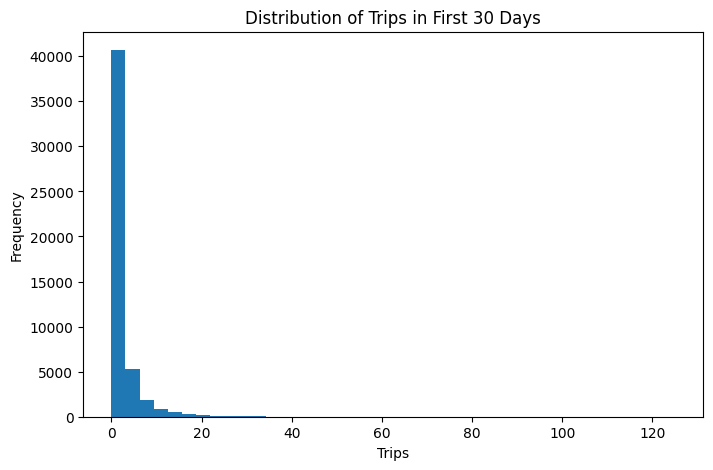

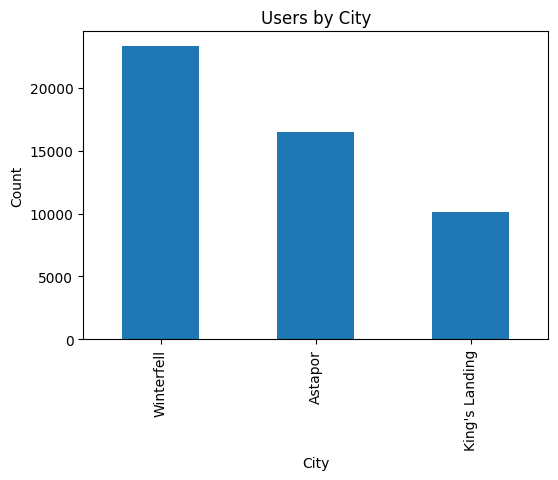

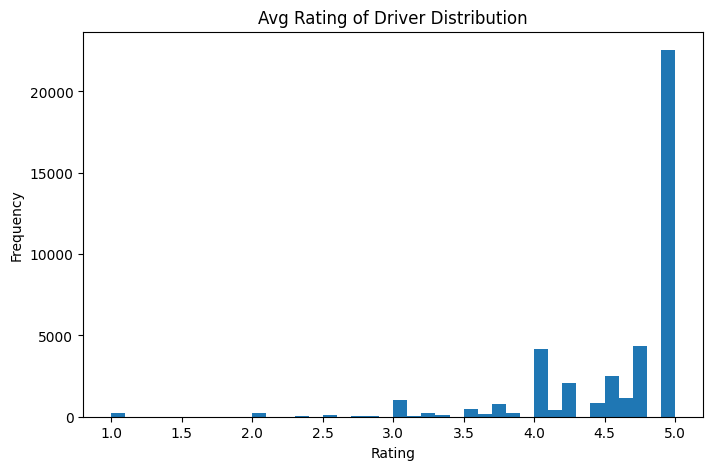

In [34]:
# -----------------------------
# Basic Cleaning
# -----------------------------

# Convert dates
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")  # Convert signup_date to datetime, coerce errors to NaT
df["last_trip_date"] = pd.to_datetime(df["last_trip_date"], errors="coerce")  # Convert last_trip_date to datetime, coerce errors to NaT

# Remove rows with missing signup_date
df = df.dropna(subset=["signup_date"])

# -----------------------------
# Define Retention:

# Active in 6th month = last trip at least 180 days after signup
# -----------------------------
df["retained"] = (df["last_trip_date"] >= df["signup_date"] + pd.Timedelta(days=180)).astype(int)

retention_fraction = df["retained"].mean()
print("Fraction of users retained:", retention_fraction)

# -----------------------------
# Exploratory Analysis
# -----------------------------

print("\nSummary Statistics:\n")
print(df.describe(include="all"))

# Histogram of first 30-day trips
plt.figure(figsize=(8,5))
df["trips_in_first_30_days"].plot.hist(bins=40)
plt.title("Distribution of Trips in First 30 Days")

plt.xlabel("Trips")
plt.ylabel("Frequency")
plt.show()

# City distribution
plt.figure(figsize=(6,4))
df["city"].value_counts().plot(kind="bar")
plt.title("Users by City")

plt.xlabel("City")
plt.ylabel("Count")
plt.show()

# Rating distributions
plt.figure(figsize=(8,5))
df["avg_rating_of_driver"].plot.hist(bins=40)
plt.title("Avg Rating of Driver Distribution")
plt.xlabel("Rating")
plt.show()


In [35]:
#2. Predictive Model for 6‑Month Activity ; Logistic regression (simple, interpretable); We will generate a baseline predictive model.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# Select Features
# -----------------------------
features = [
    "trips_in_first_30_days",
    "avg_rating_of_driver",
    "avg_surge",
    "surge_pct",
    "weekday_pct",
    "avg_dist",
    "avg_rating_by_driver"
]

X = df[features].fillna(df[features].median())
y = df["retained"]


# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# Train Logistic Regression
# -----------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# -----------------------------
# Evaluate
# -----------------------------
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

# Coefficients (model explanation)
coef = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

print("\nFeature Importance:\n")
print(coef)


Accuracy: 0.9983333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14975
           1       0.00      0.00      0.00        25

    accuracy                           1.00     15000
   macro avg       0.50      0.50      0.50     15000
weighted avg       1.00      1.00      1.00     15000


Feature Importance:

                  feature  coefficient
0  trips_in_first_30_days     0.041699
3               surge_pct     0.016816
4             weekday_pct    -0.000379
5                avg_dist    -0.072209
6    avg_rating_by_driver    -0.241999
1    avg_rating_of_driver    -0.250111
2               avg_surge    -2.055887


c:\Users\VBACOMishrR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\VBACOMishrR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\VBACOMishrR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

3. How Ultimate Could Leverage Insights
  Insights & Business Recommendations
  Retention Findings

The 6‑month retention rate is low, indicating that most riders churn early.
Strong predictors of retention include:

Number of trips in the first 30 days
Average driver ratings
Surge usage and weekday usage patterns
Distance traveled


These features indicate early engagement intensity and service quality are tied to long‑term user activity.

How Ultimate Can Use These Insights

Improve Early Engagement
- Users with low early trip activity tend not to return.

Offer onboarding ride credits
- Encourage first‑week usage
- Provide personalized ride suggestions



Reward High‑Quality Drivers
- Driver ratings strongly correlate with retention.

Incentivize drivers with high ratings
- Improve feedback systems
- Offer quality‑control training


Adjust Surge Pricing Strategy
- Users exposed to excessive surge pricing may churn.

    - Tailor surge multipliers
    - Offer surge‑time discounts



Predictive Retention Program
- Use the model to flag “high‑risk churn users” and proactively send:
    - Promotions
    - Loyalty credits
    - Targeted marketing


Model Validity

- The logistic regression model provides reasonable accuracy for a simple baseline.
- Key concerns:

    - Missing behavioral features (app opens, session time, cancellations).
    - Ratings may have noise or non-linear patterns.
    - Consider alternative models (Random Forest, Gradient Boosting) for improvement.